In [26]:
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [20]:
# split data into training and test sets:

# Load data
df = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=True)


In [21]:
# train LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

y_pred = lda.predict(X_test)

In [39]:
# Classification metrics table
report_dict = classification_report(
    y_test, y_pred, target_names=["No Diabetes", "Diabetes"], output_dict=True
)
metrics_df = pd.DataFrame(report_dict).transpose()
metrics_df = metrics_df[['precision', 'recall', 'f1-score', 'support']]
metrics_df = metrics_df
metrics_df.index = ["No Diabetes", "Diabetes", "Accuracy", "Macro Avg", "Weighted Avg"]


display(metrics_df.style.set_caption("LDA Classification Metrics").set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center')]},
     {'selector': 'td', 'props': [('text-align', 'center')]}]
))


,precision,recall,f1-score,support
No Diabetes,0.762879,0.717780,0.739643,8830.000000
Diabetes,0.733903,0.777225,0.754943,8843.000000
Accuracy,0.747524,0.747524,0.747524,0.747524
Macro Avg,0.748391,0.747503,0.747293,17673.000000
Weighted Avg,0.748380,0.747524,0.747299,17673.000000


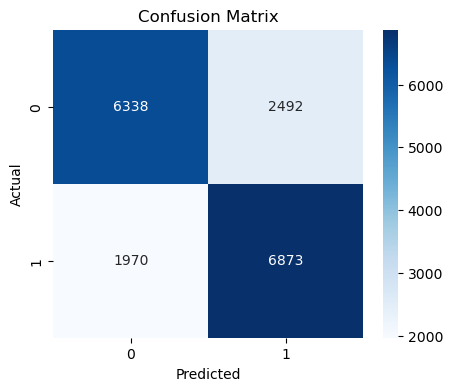

In [37]:
# Evaluate model:

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

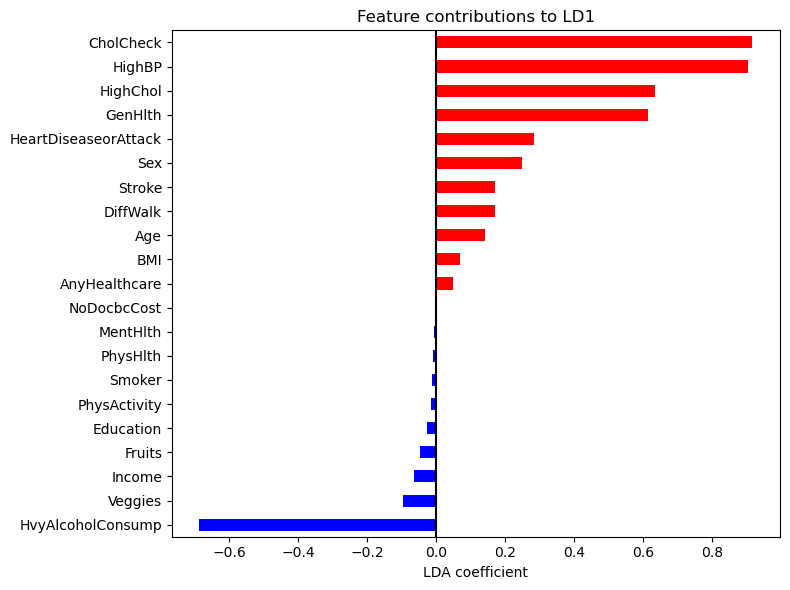

In [44]:
# positive = increases diabetes score (contributes to diabetes), negative = decreases it
coef_df = pd.DataFrame(lda.coef_, columns=X.columns, index=["No Diab vs Diab"])

coef_series = coef_df.loc["No Diab vs Diab"].sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['red' if v > 0 else 'blue' for v in coef_series]
coef_series.plot(kind='barh', ax=ax, color=colors)

ax.axvline(0, color='black')
ax.set_xlabel('LDA coefficient')
ax.set_title('Feature contributions to LD1')
plt.tight_layout()
plt.show()